# Grover's Search Algorithm

Author: Vanessa Knight

## Objective

This notebook introduces **Grover's Search Algorithm**, one of the most famous quantum algorithms.

Grover's Algorithm searches an **unsorted database** significantly faster than any classical algorithm by using quantum superposition, phase marking, and amplitude amplification.

## Topics Covered

- Unstructured Search
- Classical vs Quantum Search
- Oracle
- Phase Flip
- Diffusion Operator
- Interference
- Measurement
- Complexity Analysis

## Learning Goals

By the end of this notebook, I should be able to:

- Explain why Grover's Algorithm is faster than classical search.
- Understand the role of the Oracle.
- Explain the Diffusion Operator.
- Describe amplitude amplification.
- Build Grover's Algorithm in Qiskit.
- Interpret measurement results.

> Grover's Algorithm combines many of the ideas introduced in the previous notebooks, including superposition, interference, measurement, and entanglement.

# 1. The Search Problem

Suppose we have an unsorted database containing four items.

```text
0 → 🍎 Apple

1 → 🍌 Banana

2 → 🍇 Grape

3 → 🍊 Orange
```

Suppose we want to find the **grape**.

### Classical Computer

A classical computer checks one item at a time.

Worst case:

```text
Apple

↓

Banana

↓

Grape ✓
```

Time complexity:

$$
O(N)
$$

### Quantum Computer

A quantum computer first creates **superposition**, allowing it to explore all possibilities simultaneously.

It then increases the probability of the correct answer using **interference**.

Time complexity:

$$
O(\sqrt{N})
$$

This quadratic speedup is what makes Grover's Algorithm important.

## Why Is Grover Faster?

Grover's Algorithm works because it repeatedly performs two operations:

1. **Oracle**
   - Marks the correct answer by changing its phase.

2. **Diffusion Operator**
   - Uses quantum interference to increase the probability of measuring the marked state.

Repeated applications of these two operations gradually amplify the probability of the correct answer while reducing the probabilities of all other states.

This process is called **Amplitude Amplification**.

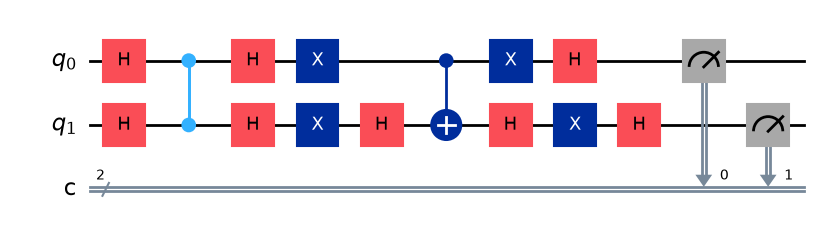

In [8]:
# Grover's Algorithm (2 Qubits)

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Two qubits represent four possible answers (2² = 4)
qc = QuantumCircuit(2, 2)

# Step 1: Create superposition
qc.h([0, 1])

# Step 2: Oracle
# Mark the target state |11⟩ by flipping its phase
qc.cz(0, 1)

# Step 3: Diffusion Operator (Amplitude Amplification)
qc.h([0, 1])
qc.x([0, 1])

qc.h(1)
qc.cx(0, 1)
qc.h(1)

qc.x([0, 1])
qc.h([0, 1])

# Step 4: Measure
qc.measure([0, 1], [0, 1])

qc.draw("mpl")

# 2. Building Grover's Algorithm

Grover's Algorithm consists of four major steps.

## Step 1 — Superposition

```python
qc.h([0,1])
```

The Hadamard gates place both qubits into superposition.

Since there are two qubits,

$$
2^2=4
$$

possible basis states now exist simultaneously:

$$
|00\rangle,\;
|01\rangle,\;
|10\rangle,\;
|11\rangle
$$

Initially, all four states have equal probability.

## Step 2 — Oracle

```python
qc.cz(0,1)
```

The Oracle **marks** the correct answer.

In this example, the marked state is

$$
|11\rangle
$$

The CZ gate flips the **phase** of this state but **does not change its measurement probability**.

Instead of changing amplitudes directly, the Oracle prepares the marked state for the next step: interference.

## Step 3 — Diffusion Operator

The Diffusion Operator performs **Amplitude Amplification**.

Its purpose is to increase the probability of measuring the marked state while decreasing the probabilities of the remaining states.

It does this through **quantum interference**.

Positive amplitudes reinforce one another.

Negative amplitudes cancel one another.

Because the Oracle previously flipped the phase of the marked state, the Diffusion Operator causes constructive interference for the correct answer.

This is the quantum "trick" that makes Grover's Algorithm work.

# 3. Understanding the Diffusion Operator

The Diffusion Operator is the heart of Grover's Algorithm.

Its purpose is to **increase the probability of measuring the marked state**.

It does **not** search the database directly.

Instead, it uses **quantum interference** to redistribute probability amplitudes.

The Oracle marks the correct answer.

The Diffusion Operator amplifies it.

## Breaking Down the Diffusion Operator

The diffusion operator is implemented as

```python
qc.h([0,1])
qc.x([0,1])

qc.h(1)
qc.cx(0,1)
qc.h(1)

qc.x([0,1])
qc.h([0,1])
```

Rather than memorizing this sequence, it helps to understand what each section is doing.

### Step 1 — Change the Basis

```python
qc.h([0,1])
```

The Hadamard gates move the computation into another basis.

This makes it possible for interference to occur during the next operations.

Think of the Hadamard as changing the "coordinate system" in which the amplitudes are manipulated.

### Step 2 — Reflect the State

```python
qc.x([0,1])
```

The X gates temporarily change the computational basis.

Together with the following controlled operation, they perform a mathematical reflection that is part of the amplitude amplification process.

Although these X gates may look unnecessary at first, they are an essential part of the diffusion operator.

### Step 3 — Phase Reflection

```python
qc.h(1)
qc.cx(0,1)
qc.h(1)
```

Remember one of the identities from Notebook 1:

$$
HZH = X
$$

This sequence allows us to perform the required phase reflection using the available quantum gates.

This is one reason Hadamard gates appear so often in quantum algorithms—they allow us to change between different computational bases.

### Step 4 — Undo the Temporary Changes

```python
qc.x([0,1])
qc.h([0,1])
```

The final X and Hadamard gates return the qubits to the original computational basis.

After completing all four steps, the probability amplitude of the marked state has increased.

Repeating the Oracle and Diffusion Operator multiple times continues amplifying the probability of the correct answer.

In [9]:
# Execute Grover's Algorithm

backend = AerSimulator()

job = backend.run(qc, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

{'11': 1000}


# 4. Understanding the Measurement Results

After executing the circuit, you should observe one measurement outcome occurring much more frequently than the others.

For example,

```text
{'11': 1000}
```

or something very close to

```text
{'11': 995,
 '10': 3,
 '01': 2}
```

depending on the simulator or hardware.

Because the Oracle marked

$$
|11\rangle
$$

the Diffusion Operator amplified its probability.

When the qubits are measured, the marked state is therefore the most likely outcome.

## Why Doesn't the Oracle Change the Measurement?

One of the easiest misconceptions is to think that the Oracle directly changes the answer.

It does **not**.

The Oracle only changes the **phase** of the marked state.

Immediately after the Oracle,

- the probabilities are unchanged,
- only the phase has changed.

The Diffusion Operator then uses that phase difference to create constructive interference for the marked state.

Without the Diffusion Operator, the Oracle alone would not improve the probability of measuring the correct answer.

### Oracle vs. Diffusion Operator

Think of Grover's Algorithm as a two-step process.

### Oracle

- Marks the correct answer.
- Changes the phase.
- Does **not** increase the measurement probability.

### Diffusion Operator

- Uses interference.
- Amplifies the marked state's probability.
- Makes the correct answer much more likely to be measured.

Neither step is sufficient by itself.

The speedup comes from repeatedly applying **both** operations together.

In [10]:
print("Qubits :", qc.num_qubits)
print("Depth  :", qc.depth())
print("Size   :", qc.size())
print("Operations:")
print(qc.count_ops())

Qubits : 2
Depth  : 10
Size   : 16
Operations:
OrderedDict({'h': 8, 'x': 4, 'measure': 2, 'cz': 1, 'cx': 1})


# 5. Resource Analysis

As quantum software engineers, we don't just ask whether an algorithm works.

We also ask:

- How many qubits does it require?
- How many gates does it use?
- How deep is the circuit?
- How many expensive two-qubit gates are present?

For this implementation of Grover's Algorithm, you should observe values similar to:

- **Qubits:** 2
- **Depth:** Approximately 10
- **Size:** Depends on the Qiskit version and optimization.
- **CX/CZ Gates:** These are particularly important because two-qubit gates are generally noisier than single-qubit gates.

Notice that the **depth** is smaller than simply counting every gate.

This is because operations acting on different qubits can often execute **in parallel**, reducing the total number of sequential layers.

# Notebook Summary

Congratulations! You have completed Grover's Search Algorithm.

## Concepts Learned

✅ Classical vs. Quantum Search

✅ Oracle

✅ Phase Flip

✅ Diffusion Operator

✅ Amplitude Amplification

✅ Quantum Interference

✅ Measurement

✅ Complexity Analysis

## Key Ideas

- Grover's Algorithm searches an **unsorted database**.
- Classical search requires

$$
O(N)
$$

operations.

- Grover's Algorithm requires approximately

$$
O(\sqrt{N})
$$

operations.

- The Oracle marks the correct answer by changing its **phase**.
- The Diffusion Operator amplifies the probability of the marked state through **interference**.
- Measurement reveals the marked state with high probability.

# Quick Self-Review

Try answering these questions without looking back.

1. What problem does Grover's Algorithm solve?

2. What is the purpose of the Oracle?

3. Does the Oracle increase the probability of the correct answer?

4. What does the Diffusion Operator do?

5. What is amplitude amplification?

6. What is constructive interference?

7. Why is the Hadamard gate used at the beginning of Grover's Algorithm?

8. Why is the CZ gate used as the Oracle in this example?

9. Why is Grover faster than a classical search?

10. What is the approximate time complexity of Grover's Algorithm?

If you can confidently answer these questions, you're ready to study the Quantum Fourier Transform.

# Key Takeaways

- Grover's Algorithm is one of the first examples of a quantum speedup.
- Superposition allows all possible states to be explored simultaneously.
- The Oracle identifies the correct answer by changing its phase.
- The Diffusion Operator uses interference to amplify the marked state's probability.
- The algorithm succeeds because phase differences are converted into measurable probability differences.
- Understanding Grover's Algorithm provides a strong foundation for more advanced quantum algorithms.